# Classification with NN

In [8]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.layers import Flatten, Dense, Input
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.utils import set_random_seed, plot_model
from sklearn.utils import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [9]:
# Setting reproducible seed
seed = 100
random.seed(seed)
np.random.seed(seed)
set_random_seed(seed)

## Loading the Data

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
# Path to the dataset root folder containing the class subfolders
data_dir = "/content/drive/MyDrive/bahrain-currency"

# parameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Load training dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=seed,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
)

# Load validation dataset
val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=seed,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
)

# Print detected class names (folder names)
class_names = train_ds.class_names
num_classes = len(class_names)
print("\nClasses found:", class_names)
print("Total Classes:", num_classes)

Found 1082 files belonging to 9 classes.
Using 866 files for training.
Found 1082 files belonging to 9 classes.
Using 216 files for validation.

Classes found: ['100', '25', '5', '50', '500', 'Five', 'One', 'Ten', 'Twenty']
Total Classes: 9


In [12]:
train_ds

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [13]:
for images, labels in train_ds.take(1):
    print(images.shape)
    print(labels.shape)

(32, 224, 224, 3)
(32,)


### Scaling

In [14]:
# Scaling Layer (can do it manual x/255.0)
normalization_layer = layers.Rescaling(1./255)

train_ds_scaled = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds_scaled = val_ds.map(lambda x, y: (normalization_layer(x), y))

### Preprocessing

In [15]:
# To make the process more efficient (Optimizing input pipeline)
AUTOTUNE = tf.data.AUTOTUNE
# training pipe
train_ds_scaled = train_ds_scaled.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
# validation pipe
val_ds_scaled = val_ds_scaled.cache().prefetch(buffer_size=AUTOTUNE)

### EXPLORATORY DATA ANALYSIS (EDA)

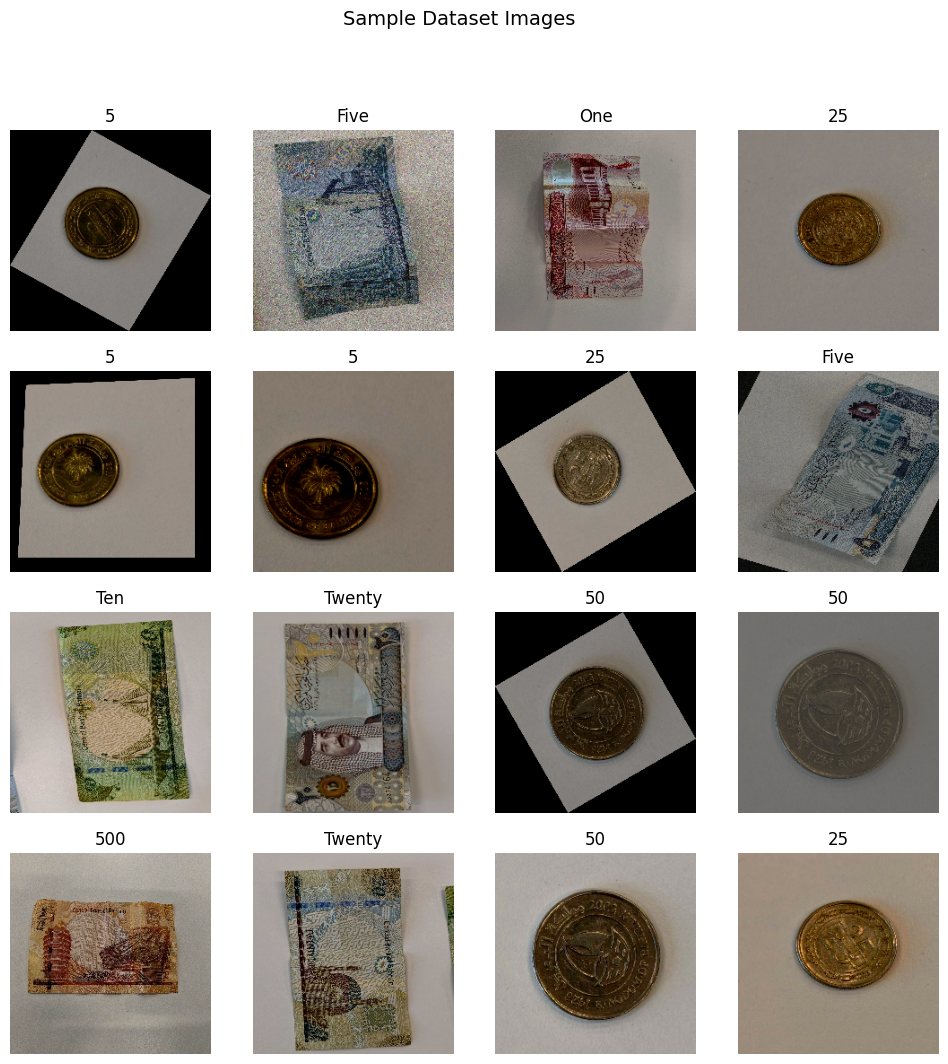

In [16]:
# Sample Image Grid
plt.figure(figsize=(12, 12))
for images, labels in train_ds.take(1):
    for i in range(min(16, len(images))):
        plt.subplot(4, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.suptitle("Sample Dataset Images", fontsize=14)
plt.show()

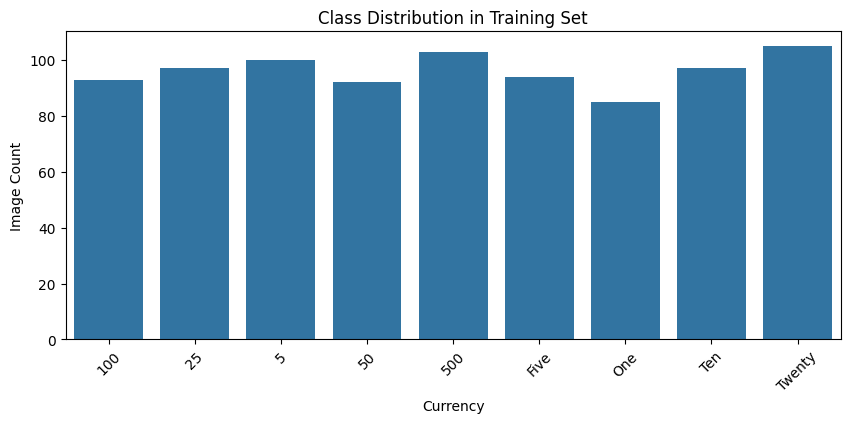

In [17]:
# Class Distribution Analysis
y_train_list = []
for _, labels in train_ds:
    y_train_list.extend(labels.numpy())

class_counts = pd.Series(y_train_list).value_counts().sort_index()
plt.figure(figsize=(10, 4))
sns.barplot(x=[class_names[i] for i in class_counts.index], y=class_counts.values)
plt.title("Class Distribution in Training Set")
plt.xlabel("Currency")
plt.ylabel("Image Count")
plt.xticks(rotation=45)
plt.show()

#### Class weight

In [18]:
classes_unique = np.unique(y_train_list)
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes_unique,
    y=np.array(y_train_list)
)
class_weights_dict = dict(zip(classes_unique, weights))
print("\nComputed Class Weights:", class_weights_dict)


Computed Class Weights: {np.int32(0): np.float64(1.034647550776583), np.int32(1): np.float64(0.9919816723940436), np.int32(2): np.float64(0.9622222222222222), np.int32(3): np.float64(1.0458937198067633), np.int32(4): np.float64(0.9341963322545846), np.int32(5): np.float64(1.0236406619385343), np.int32(6): np.float64(1.1320261437908496), np.int32(7): np.float64(0.9919816723940436), np.int32(8): np.float64(0.9164021164021164)}


## Building Models

### Modeling using Seq API

In [20]:
seq_model = Sequential()
seq_model.add(Flatten(input_shape=(224, 224, 3))) # image 2D - > 1D

seq_model.add(Dense(500, activation='relu'))
seq_model.add(Dense(200, activation='relu'))
seq_model.add(Dense(100, activation='relu'))

seq_model.add(Dense(num_classes, activation='softmax')) # output layer

# model compilation
seq_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['acc']
)

print("\n--- Sequential Model Summary ---")
seq_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



--- Sequential Model Summary ---


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 150528)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 500)            │    75,264,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 200)            │       100,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 9)              │           909 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,385,709 (287.57 MB)

 Trainable params: 75,385,709 (287.57 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
history = seq_model.fit(train_ds_scaled, validation_data=val_ds_scaled, epochs=10, class_weight=class_weights_dict)

Epoch 1/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 112s 2s/step - acc: 0.1524 - loss: 35.9408 - val_acc: 0.1898 - val_loss: 17.2066
Epoch 2/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - acc: 0.3349 - loss: 7.5085 - val_acc: 0.5000 - val_loss: 4.3792
Epoch 3/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - acc: 0.6132 - loss: 2.1485 - val_acc: 0.6389 - val_loss: 1.5311
Epoch 4/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - acc: 0.7067 - loss: 1.2604 - val_acc: 0.6667 - val_loss: 1.3102
Epoch 5/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - acc: 0.7529 - loss: 1.0399 - val_acc: 0.7454 - val_loss: 0.9889
Epoch 6/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - acc: 0.7113 - loss: 1.2703 - val_acc: 0.7130 - val_loss: 1.0636
Epoch 7/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - acc: 0.7921 - loss: 0.7475 - val_acc: 0.6991 - val_loss: 1.0499
Epoch 8/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - acc: 0.8372 - loss: 0.5874 - val_acc: 0.7037 - val_loss: 0.9608
Epoch 9/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - acc: 0.78

### Modeling using Functional API

In [22]:
inputs = Input(shape=(224, 224, 3))
x = Flatten()(inputs)
x = Dense(500, activation='relu')(x)
x = Dense(200, activation='relu')(x)
x = Dense(100, activation='relu')(x)
outputs = Dense(num_classes, activation='softmax')(x)

func_model = Model(inputs=inputs, outputs=outputs)

func_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['acc']
)

print("\n--- Functional Model Summary ---")
func_model.summary()


--- Functional Model Summary ---


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 150528)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 500)            │    75,264,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 200)            │       100,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 9)              │           909 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,385,709 (287.57 MB)

 Trainable params: 75,385,709 (287.57 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
history_f = func_model.fit(train_ds_scaled, validation_data=val_ds_scaled, epochs=10, class_weight=class_weights_dict)

Epoch 1/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - acc: 0.1409 - loss: 49.0302 - val_acc: 0.1713 - val_loss: 15.1566
Epoch 2/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - acc: 0.3106 - loss: 7.2219 - val_acc: 0.3796 - val_loss: 9.5079
Epoch 3/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - acc: 0.5081 - loss: 4.0557 - val_acc: 0.6296 - val_loss: 1.3564
Epoch 4/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - acc: 0.6871 - loss: 1.4022 - val_acc: 0.8148 - val_loss: 0.6128
Epoch 5/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - acc: 0.7794 - loss: 0.8194 - val_acc: 0.5833 - val_loss: 1.5845
Epoch 6/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - acc: 0.6605 - loss: 2.3154 - val_acc: 0.4722 - val_loss: 3.1912
Epoch 7/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - acc: 0.6848 - loss: 1.8225 - val_acc: 0.7361 - val_loss: 1.3720
Epoch 8/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - acc: 0.8025 - loss: 0.6858 - val_acc: 0.7685 - val_loss: 0.8140
Epoch 9/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - acc: 0.87

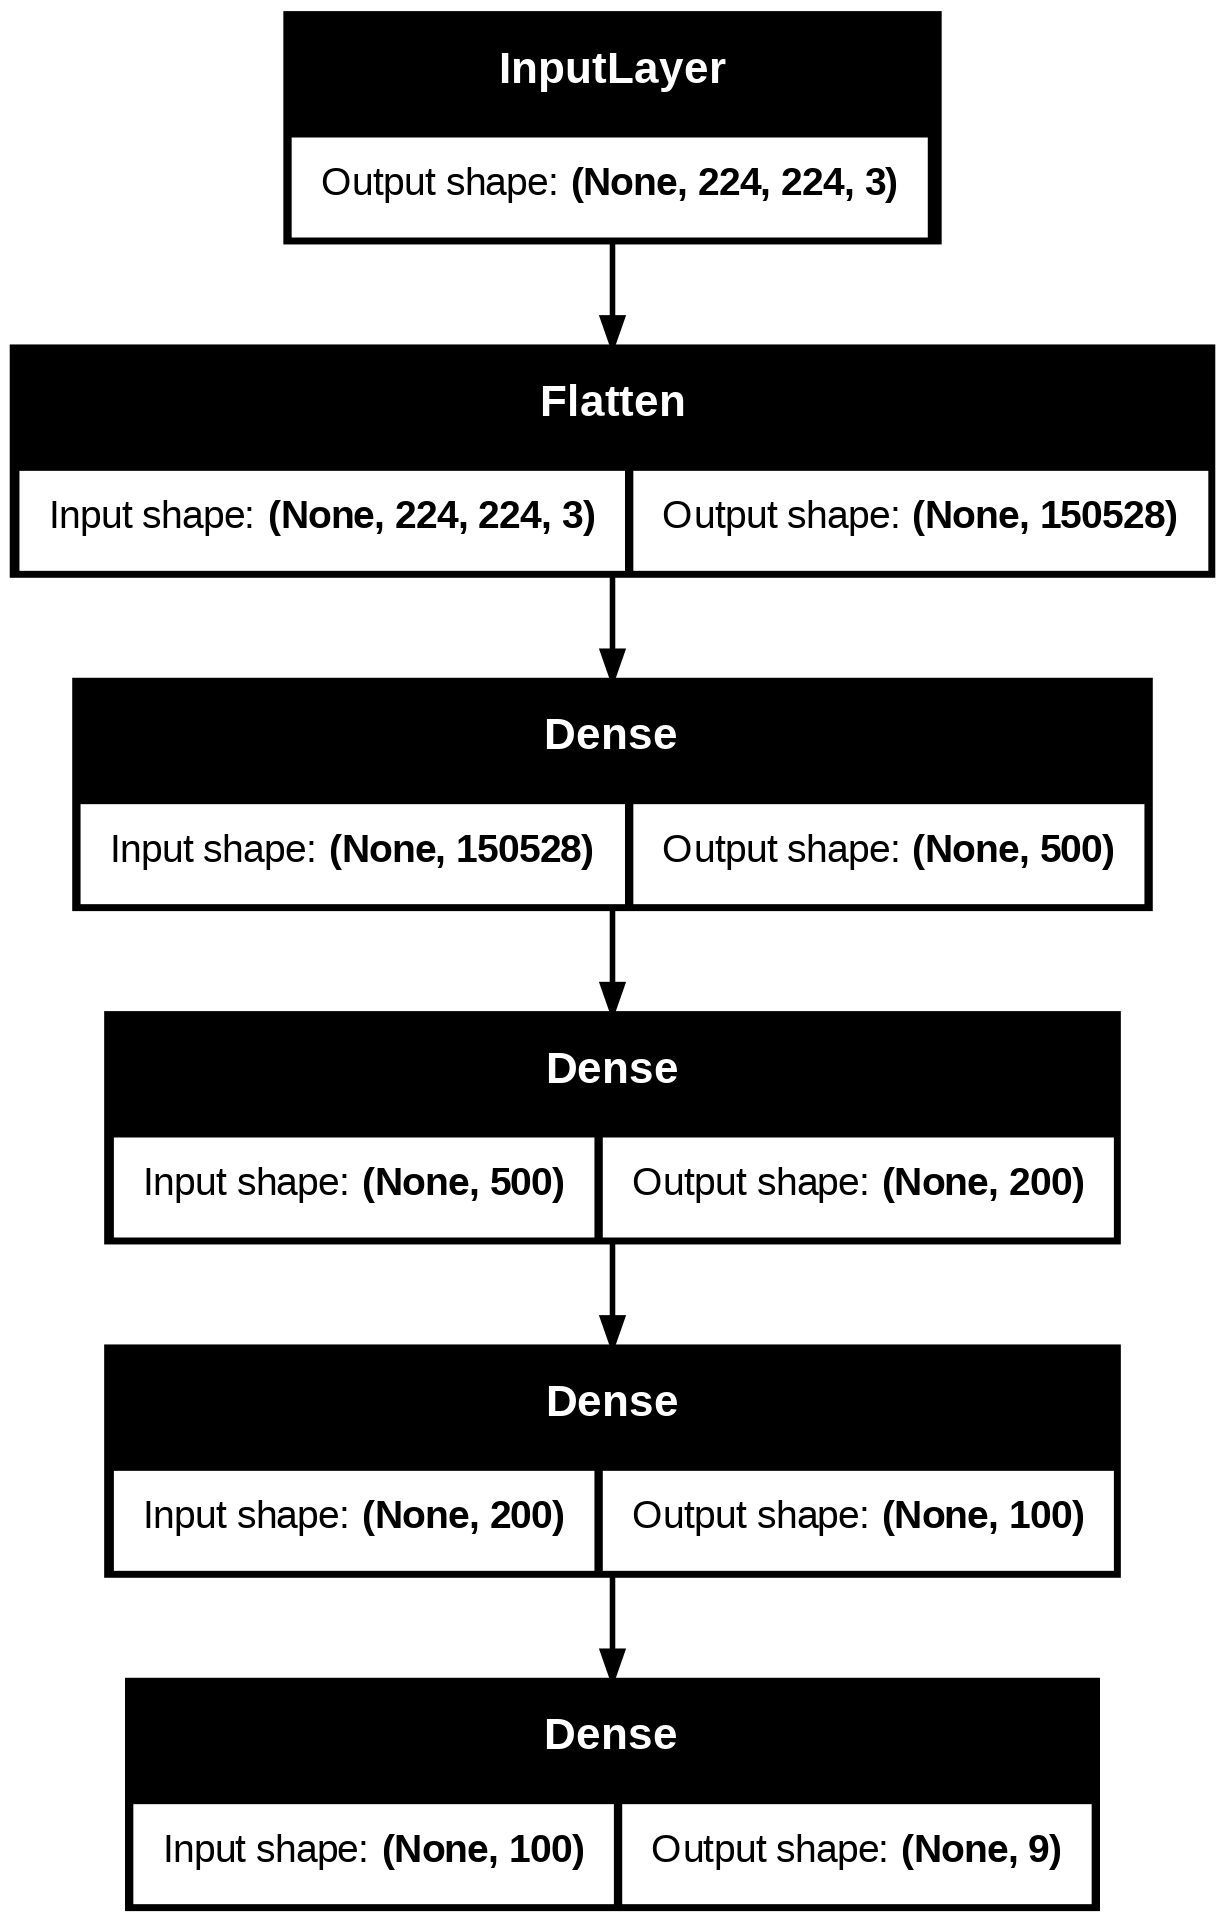

In [24]:
plot_model(func_model, show_shapes=True)

## History

Plot Training Curves (History Analysis) using the Seq model output

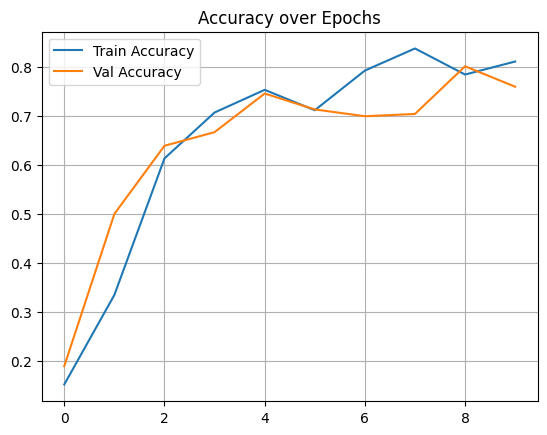

In [25]:
# Plot Training Curves (History Analysis)
history_df = pd.DataFrame(history.history)

plt.plot(history_df['acc'], label='Train Accuracy')
plt.plot(history_df['val_acc'], label='Val Accuracy')
plt.title('Accuracy over Epochs')
plt.legend()
plt.grid(True)

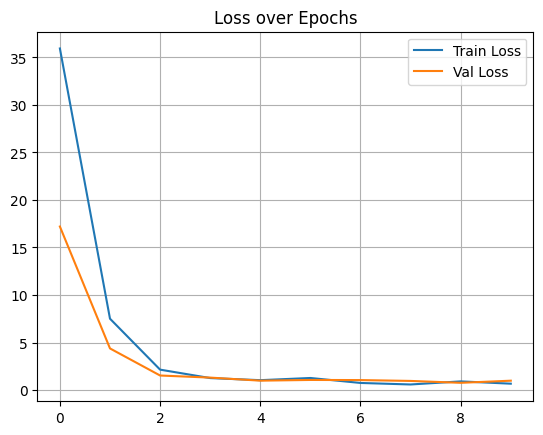

In [26]:
plt.plot(history_df['loss'], label='Train Loss')
plt.plot(history_df['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.legend()
plt.grid(True)
plt.show()

## History

Plot Training Curves (History Analysis) using the Func model output

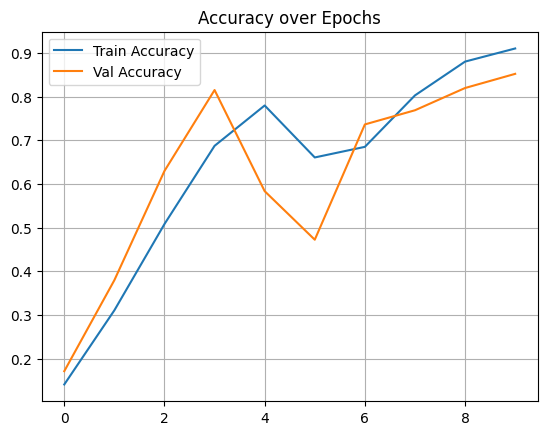

In [29]:
# Plot Training Curves (History Analysis)
history_df = pd.DataFrame(history_f.history)

plt.plot(history_df['acc'], label='Train Accuracy')
plt.plot(history_df['val_acc'], label='Val Accuracy')
plt.title('Accuracy over Epochs')
plt.legend()
plt.grid(True)

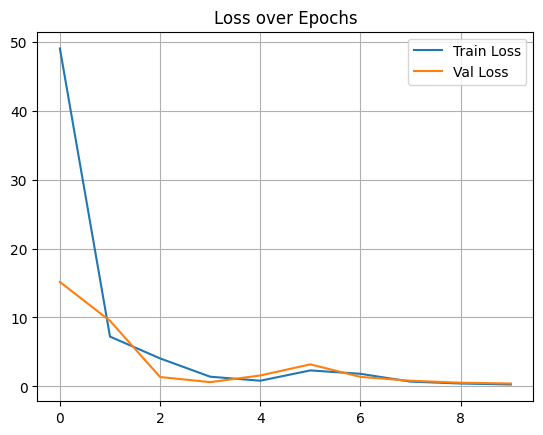

In [30]:
plt.plot(history_df['loss'], label='Train Loss')
plt.plot(history_df['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.legend()
plt.grid(True)
plt.show()

## EVALUATION & ERROR ANALYSIS

This is on the Validation Data

In [31]:
# Collecting all the truths and predictions from validation set
y_true = []
y_pred_probs = []
x_val_images = []

for images, labels in val_ds_scaled:
    preds = func_model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred_probs.extend(preds)
    x_val_images.extend(images.numpy())

y_true = np.array(y_true)
y_pred_probs = np.array(y_pred_probs)
y_pred_labels = np.argmax(y_pred_probs, axis=1) # predicted labels

### Error Analysis

In [32]:
print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred_labels, target_names=class_names))


--- Classification Report ---
              precision    recall  f1-score   support

         100       0.88      0.81      0.85        27
          25       0.86      0.79      0.83        24
           5       0.76      0.80      0.78        20
          50       0.86      0.89      0.88        28
         500       0.65      0.88      0.75        17
        Five       1.00      1.00      1.00        26
         One       0.88      0.86      0.87        35
         Ten       0.86      0.75      0.80        24
      Twenty       0.87      0.87      0.87        15

    accuracy                           0.85       216
   macro avg       0.85      0.85      0.85       216
weighted avg       0.86      0.85      0.85       216



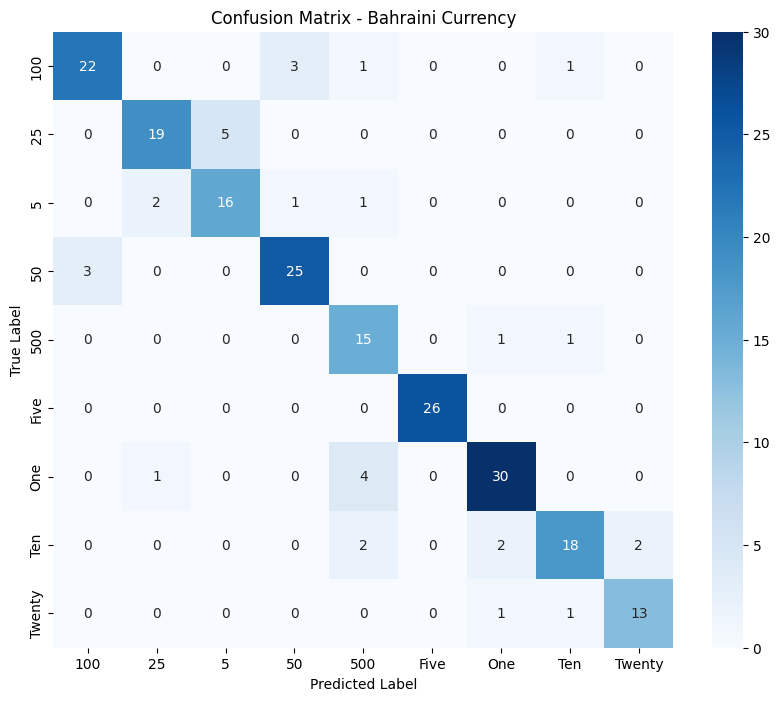

In [33]:
# Confusion Matrix Heatmap
conf_matrix = confusion_matrix(y_true, y_pred_labels)

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Bahraini Currency')
plt.show()

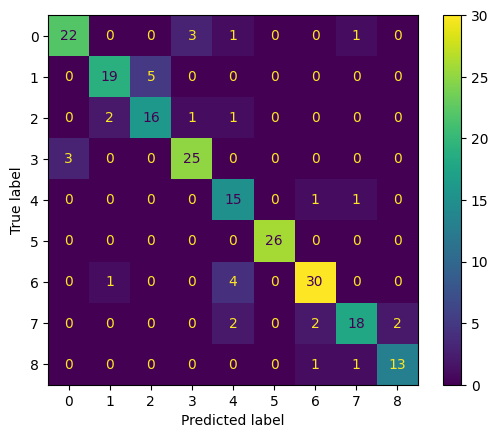

In [34]:
ConfusionMatrixDisplay.from_predictions(y_true, y_pred_labels);


Total Misclassified Images: 32 out of 216


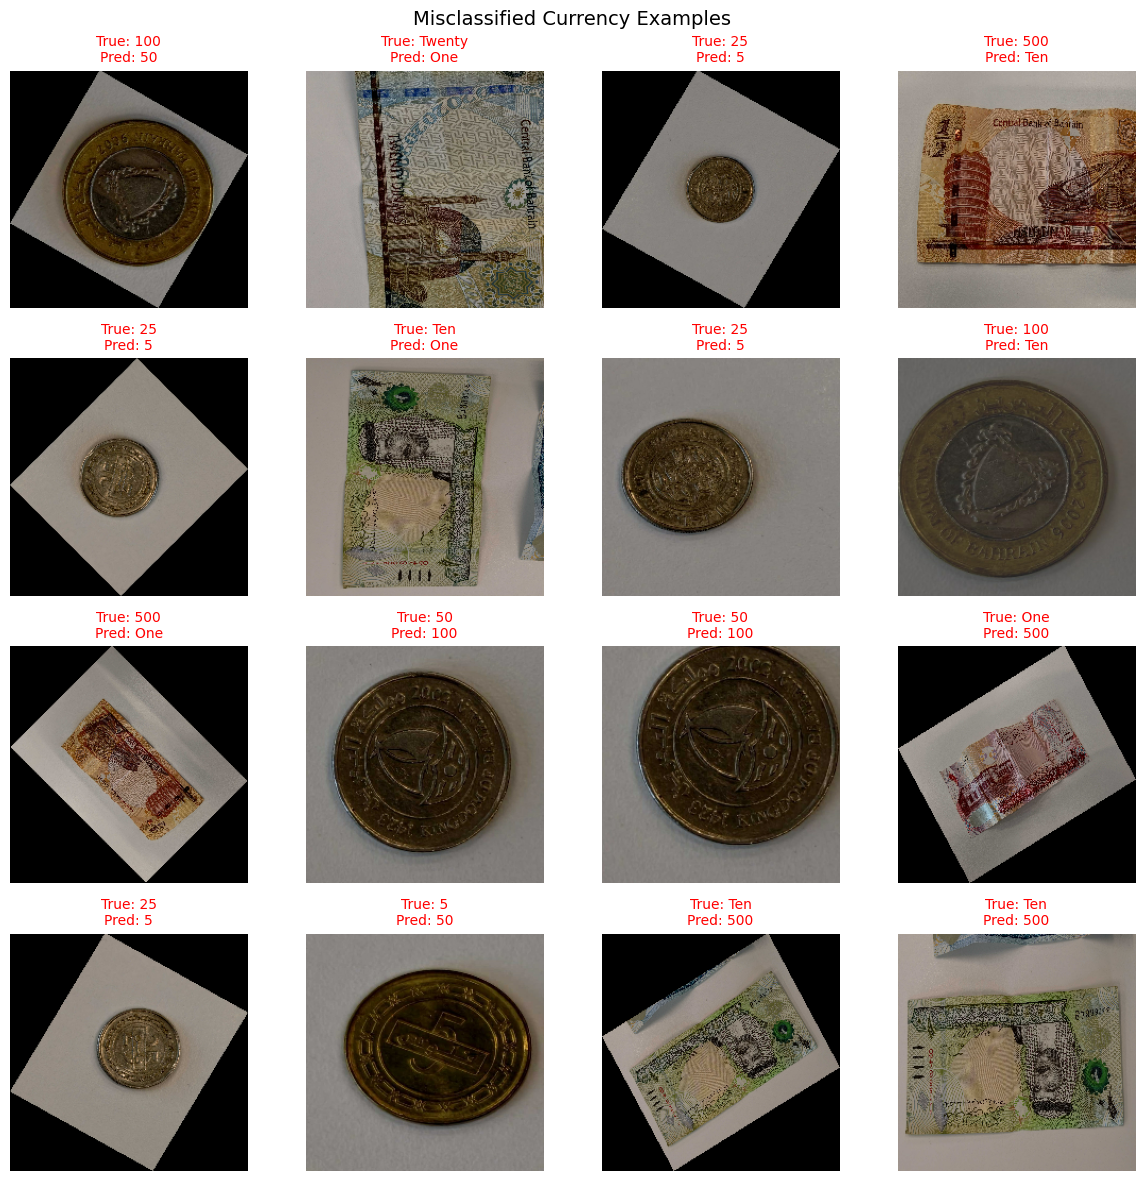

In [35]:
# Misclassified Samples Visualization
misclassified_idx = np.where(y_true != y_pred_labels)[0]
print(f"\nTotal Misclassified Images: {len(misclassified_idx)} out of {len(y_true)}")

if len(misclassified_idx) > 0:
    plt.figure(figsize=(12, 12))
    num_to_show = min(16, len(misclassified_idx))
    for i in range(num_to_show):
        idx = misclassified_idx[i]
        plt.subplot(4, 4, i + 1)
        plt.imshow(x_val_images[idx])
        plt.title(f"True: {class_names[y_true[idx]]}\nPred: {class_names[y_pred_labels[idx]]}", color='red', fontsize=10)
        plt.axis('off')
    plt.suptitle("Misclassified Currency Examples", fontsize=14)
    plt.tight_layout()
    plt.show()

## Deployment

In [36]:
# 1. Save the trained Keras model
model_save_path = "/content/drive/MyDrive/bahrain_currency_model.keras"
seq_model.save(model_save_path)
print(f"Model saved successfully to: {model_save_path}")

# 2. Save class names to a JSON file for the Streamlit app to map predictions correctly
class_names_path = "/content/drive/MyDrive/class_names.json"
with open(class_names_path, "w") as f:
    json.dump(class_names, f)
print(f"Class names saved successfully to: {class_names_path}")

Model saved successfully to: /content/drive/MyDrive/bahrain_currency_model.keras
Class names saved successfully to: /content/drive/MyDrive/class_names.json
